# Benchmark 1: throughput vs concurrency
Steady-state write throughput at concurrency 1/10/50/100, single-node baseline vs cluster. Run `bench/01-throughput-sweep.sh` first.

In [1]:
import sys
sys.path.insert(0, ".")
import matplotlib.pyplot as plt
from plot_style import load, agg


In [2]:
df = load("throughput-sweep.csv")
df

,clusterSize,concurrency,run,reqPerSec,p50Ms,p95Ms,p99Ms,errors
0,1,1,1,171.94,5.61,5.98,157.63,0
1,1,1,2,177.15,5.60,5.98,6.14,0
2,1,1,3,176.38,5.63,5.94,6.09,0
3,1,1,4,173.66,5.64,5.99,11.63,0
4,1,1,5,174.80,5.65,6.00,6.13,0
5,1,10,1,1130.50,7.00,7.44,7.73,0
6,1,10,2,1083.15,7.32,7.71,7.92,0
7,1,10,3,1047.48,7.58,8.00,8.15,0
8,1,10,4,981.30,8.10,8.51,8.71,0
9,1,10,5,945.40,8.40,8.82,9.10,0


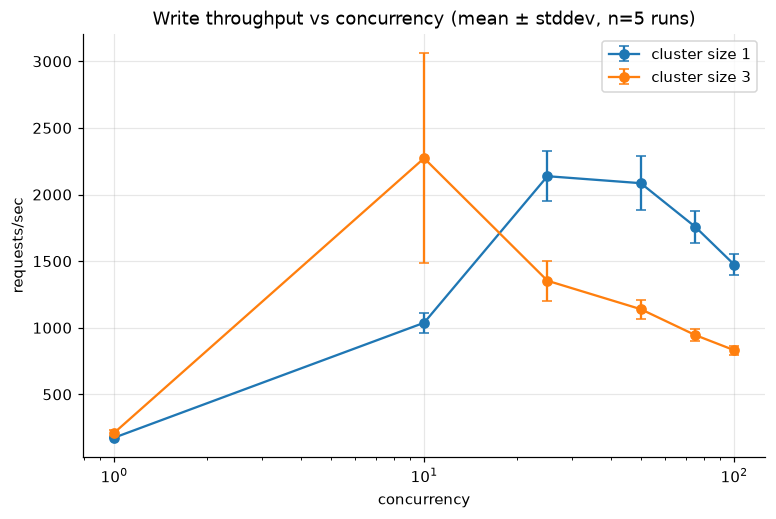

In [3]:
summary = agg(df, ["clusterSize", "concurrency"], "reqPerSec")

fig, ax = plt.subplots()
for size, group in summary.groupby("clusterSize"):
    group = group.sort_values("concurrency")
    ax.errorbar(group["concurrency"], group["mean"], yerr=group["std"],
                marker="o", capsize=3, label=f"cluster size {size}")
ax.set_xscale("log")
ax.set_xlabel("concurrency")
ax.set_ylabel("requests/sec")
ax.set_title(f"Write throughput vs concurrency (mean ± stddev, n={df['run'].nunique()} runs)")
ax.legend()
plt.show()

### Plateau detection
The plateau (where added concurrency stops buying throughput) matters more than the peak - it's the point where replication/IO, not client load, is the bottleneck.

In [4]:
for size, group in summary.groupby("clusterSize"):
    group = group.sort_values("concurrency").reset_index(drop=True)
    pct_change = group["mean"].pct_change() * 100
    plateau_row = group.iloc[1:][pct_change.iloc[1:].abs() < 5]
    plateau_c = plateau_row["concurrency"].iloc[0] if len(plateau_row) else None
    print(f"cluster size {size}: plateaus around concurrency={plateau_c}")

cluster size 1: plateaus around concurrency=50
cluster size 3: plateaus around concurrency=None
